# Predicción de Renuncia de Empleados mediante Aprendizaje Supervisado

Nombre: Karina Moreno

Tema: Aprendizaje Supervisado

Desarrollar modelos de Machine Learning para predecir la renuncia de empleados.

Librerías: 
En esta sección se importan las librerías necesarias para la manipulación de datos, visualización, entrenamiento de modelos de Machine Learning y evaluación de resultados.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

Cargar Dataset:
Se carga el conjunto de datos previamente generado que contiene información de 300 empleados y la variable objetivo denominada "renuncia".

In [2]:
df = pd.read_csv("datos/empleados_rrhh.csv")

df.head()

,edad,años_en_empresa,salario_mensual,horas_extra_semana,satisfaccion_laboral,num_proyectos_año,distancia_casa_trabajo_km,ultima_evaluacion_desempeño,capacitaciones_recibidas,tiene_ascenso_ultimos_2_años,renuncia
0,60,19,2610,14,3,8,61,0.76,1,0,1
1,32,7,2546,3,3,6,53,0.98,3,1,0
2,42,0,1259,11,1,1,59,0.64,3,1,1
3,24,0,1446,20,1,7,18,0.97,3,1,0
4,30,4,1897,19,4,7,44,0.70,2,1,0


Estadísticas Descriptivas:
Se calculan estadísticas descriptivas para conocer la distribución general de las variables, incluyendo medidas de tendencia central y dispersión.

In [3]:
df.describe()

,edad,años_en_empresa,salario_mensual,horas_extra_semana,satisfaccion_laboral,num_proyectos_año,distancia_casa_trabajo_km,ultima_evaluacion_desempeño,capacitaciones_recibidas,tiene_ascenso_ultimos_2_años,renuncia
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,41.053333,7.170000,2136.003333,10.200000,2.986667,5.516667,40.443333,0.708867,2.496667,0.506667,0.380000
std,11.604282,5.846512,781.754290,5.990516,1.421228,2.882839,22.912808,0.172198,1.722366,0.500791,0.486197
min,22.000000,0.000000,807.000000,0.000000,1.000000,1.000000,1.000000,0.400000,0.000000,0.000000,0.000000
25%,31.000000,2.000000,1580.250000,5.000000,2.000000,3.000000,22.000000,0.570000,1.000000,0.000000,0.000000
50%,41.000000,6.000000,1966.000000,11.000000,3.000000,5.000000,40.500000,0.705000,2.000000,1.000000,0.000000
75%,52.000000,12.000000,2569.500000,16.000000,4.000000,8.000000,60.000000,0.860000,4.000000,1.000000,1.000000
max,60.000000,19.000000,4651.000000,20.000000,5.000000,10.000000,80.000000,1.000000,5.000000,1.000000,1.000000


Heatmap (Análisis de correlación):
Se construye un mapa de calor para identificar relaciones entre las variables y detectar cuáles presentan mayor asociación con la variable objetivo.

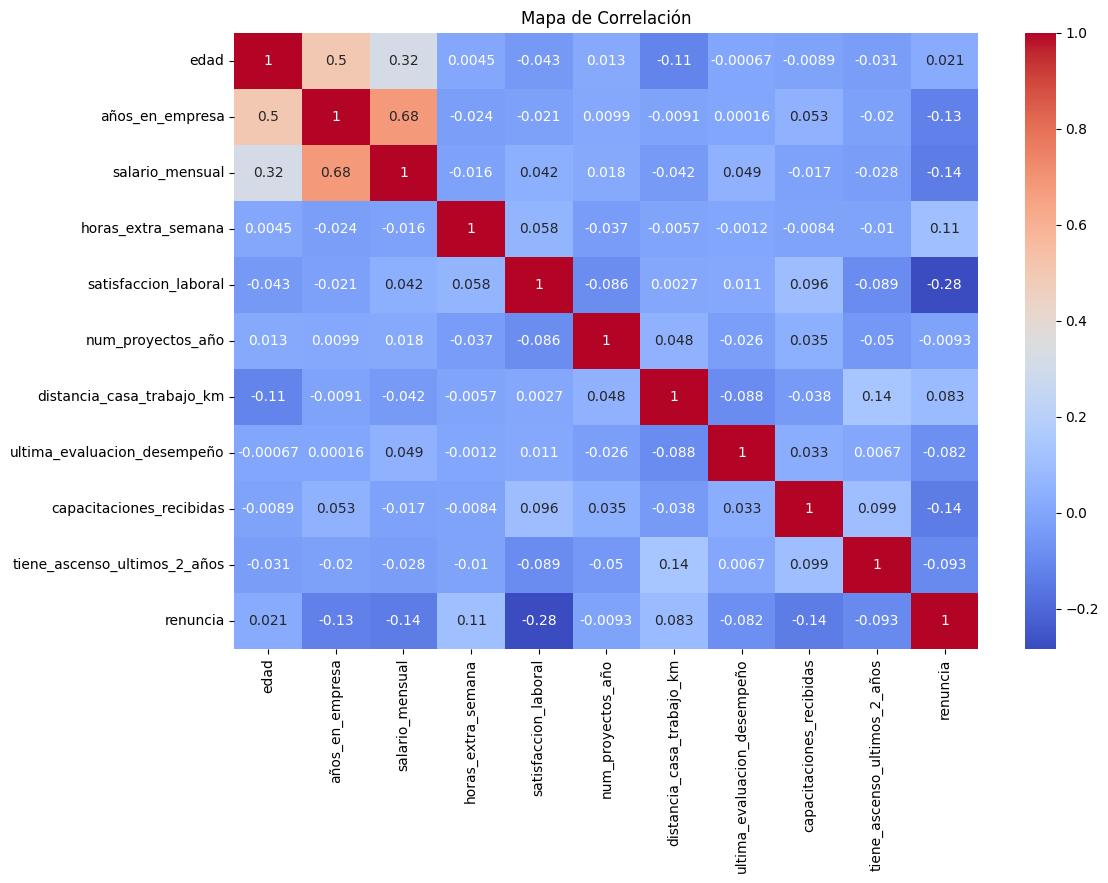

In [4]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de Correlación")

plt.show()

Distribución de Renuncia:
Se analiza la distribución de empleados que permanecen en la empresa y aquellos que presentan renuncia para verificar si existe desbalance entre las clases.

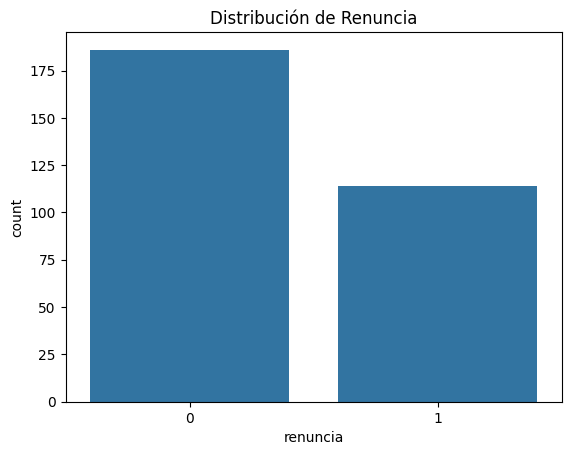

renuncia
0    186
1    114
Name: count, dtype: int64


In [5]:
sns.countplot(
    x='renuncia',
    data=df
)

plt.title("Distribución de Renuncia")

plt.show()

print(df['renuncia'].value_counts())

Boxplot Salario:
Se analiza la distribución salarial de los empleados agrupados según su condición de permanencia o renuncia.

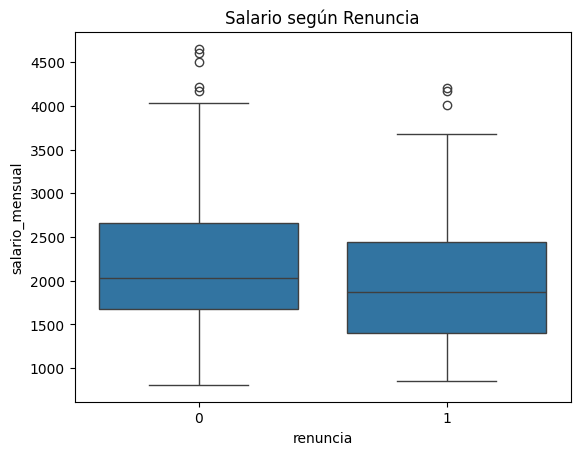

In [6]:
sns.boxplot(
    x='renuncia',
    y='salario_mensual',
    data=df
)

plt.title("Salario según Renuncia")

plt.show()

Boxplot Satisfacción:
Se compara el nivel de satisfacción laboral entre los empleados que permanecieron y aquellos que renunciaron.

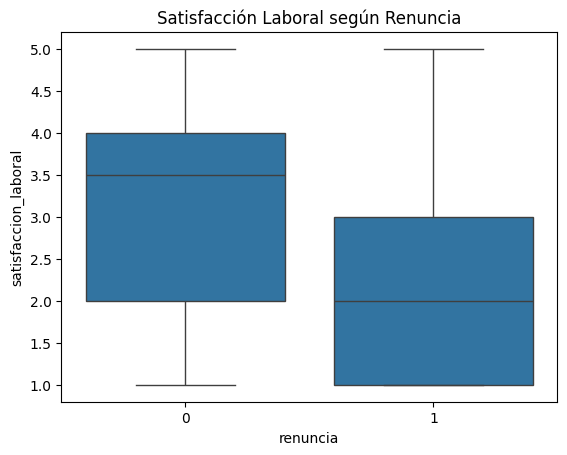

In [7]:
sns.boxplot(
    x='renuncia',
    y='satisfaccion_laboral',
    data=df
)

plt.title("Satisfacción Laboral según Renuncia")

plt.show()

Preparación de Datos:
Se separan las variables predictoras y la variable objetivo. Posteriormente se divide el dataset en conjuntos de entrenamiento y prueba utilizando una proporción de 80% y 20%.

Estandarización de Variables:
Se aplica StandardScaler para normalizar las variables numéricas. El ajuste se realiza únicamente sobre los datos de entrenamiento para evitar fuga de información.

In [8]:
X = df.drop("renuncia", axis=1)

y = df["renuncia"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression:
La Regresión Logística se utiliza como modelo base de referencia para evaluar el desempeño inicial del sistema de clasificación.

In [9]:
lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = lr.predict(X_test_scaled)

prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))
print("AUC:", roc_auc_score(y_test, prob_lr))

Accuracy: 0.6333333333333333
Precision: 0.5882352941176471
Recall: 0.4
F1: 0.47619047619047616
AUC: 0.6731428571428572


Random Forest:
Random Forest es un método de ensamble basado en múltiples árboles de decisión que busca mejorar la capacidad predictiva del modelo.

In [10]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

pred_rf = rf.predict(X_test_scaled)

prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1:", f1_score(y_test, pred_rf))
print("AUC:", roc_auc_score(y_test, prob_rf))

Accuracy: 0.6333333333333333
Precision: 0.5882352941176471
Recall: 0.4
F1: 0.47619047619047616
AUC: 0.6748571428571429


Gradient Boosting:
Gradient Boosting construye árboles de forma secuencial corrigiendo errores de iteraciones anteriores para mejorar la precisión de las predicciones.

In [11]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train_scaled,
    y_train
)

pred_gb = gb.predict(X_test_scaled)

prob_gb = gb.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, pred_gb))
print("Precision:", precision_score(y_test, pred_gb))
print("Recall:", recall_score(y_test, pred_gb))
print("F1:", f1_score(y_test, pred_gb))
print("AUC:", roc_auc_score(y_test, prob_gb))

Accuracy: 0.6833333333333333
Precision: 0.6666666666666666
Recall: 0.48
F1: 0.5581395348837209
AUC: 0.6811428571428572


Curva ROC:
Se comparan los tres modelos utilizando curvas ROC y el indicador AUC para evaluar su capacidad de discriminación entre empleados que renuncian y empleados que permanecen.

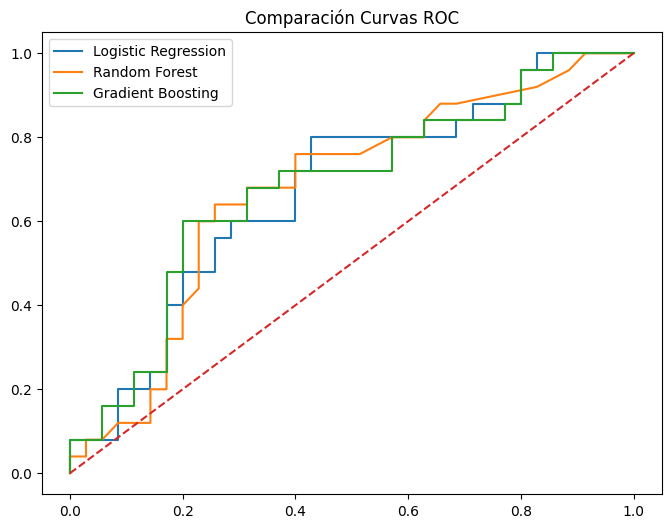

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')

plt.plot(fpr_rf, tpr_rf, label='Random Forest')

plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.title("Comparación Curvas ROC")

plt.show()

Matrices de confusión:
Las matrices de confusión permiten analizar detalladamente los aciertos y errores de clasificación de cada modelo.

-Matriz de Confusión - Logistic Regression

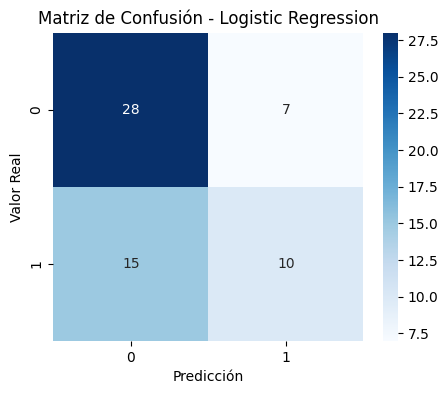

In [13]:
cm_lr = confusion_matrix(
    y_test,
    pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

-Matriz de Confusión - Random Forest

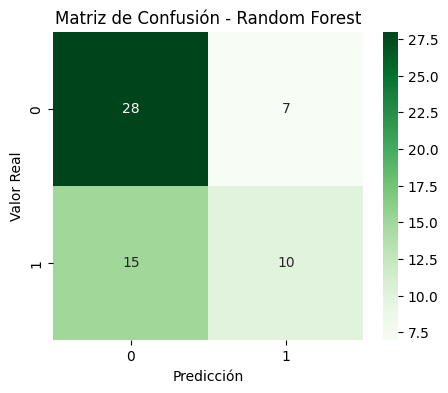

In [14]:
cm_rf = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

-Matriz de Confusión - Gradient Boosting

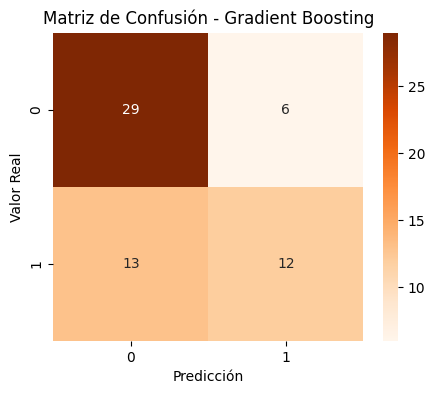

In [15]:
cm_gb = confusion_matrix(
    y_test,
    pred_gb
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Matriz de Confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

Importancia de Variables:
Se identifican las variables que tienen mayor influencia en las decisiones de los modelos Random Forest y Gradient Boosting.

-Feature Importance Random Forest

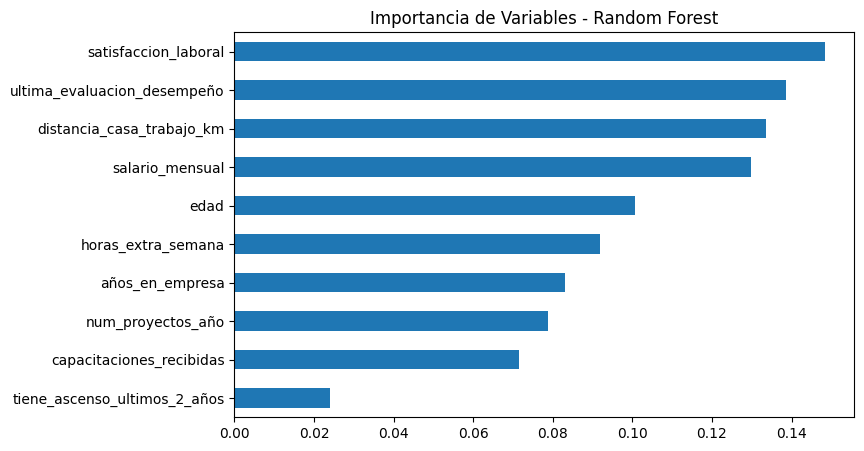

satisfaccion_laboral            0.148367
ultima_evaluacion_desempeño     0.138488
distancia_casa_trabajo_km       0.133705
salario_mensual                 0.129711
edad                            0.100603
horas_extra_semana              0.091769
años_en_empresa                 0.083029
num_proyectos_año               0.078718
capacitaciones_recibidas        0.071637
tiene_ascenso_ultimos_2_años    0.023972
dtype: float64


In [16]:
importancias_rf = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(8,5))

importancias_rf.sort_values().plot(
    kind='barh'
)

plt.title("Importancia de Variables - Random Forest")

plt.show()

print(importancias_rf.sort_values(ascending=False))

-Feature Importance Gradient Boosting

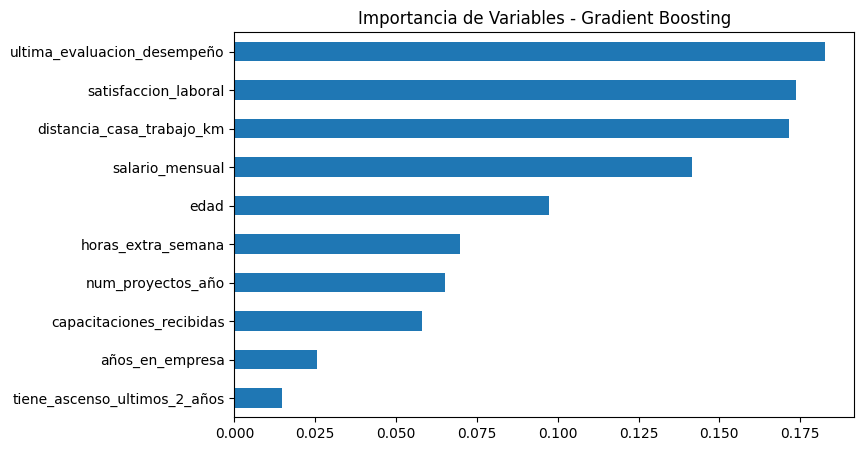

ultima_evaluacion_desempeño     0.182626
satisfaccion_laboral            0.173618
distancia_casa_trabajo_km       0.171611
salario_mensual                 0.141596
edad                            0.097191
horas_extra_semana              0.069845
num_proyectos_año               0.065104
capacitaciones_recibidas        0.057888
años_en_empresa                 0.025637
tiene_ascenso_ultimos_2_años    0.014885
dtype: float64


In [17]:
importancias_gb = pd.Series(
    gb.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(8,5))

importancias_gb.sort_values().plot(
    kind='barh'
)

plt.title("Importancia de Variables - Gradient Boosting")

plt.show()

print(importancias_gb.sort_values(ascending=False))

Cross Validation (k=5):
Se aplica validación cruzada con cinco particiones para evaluar la estabilidad y capacidad de generalización del mejor modelo.

In [18]:
scores = cross_val_score(
    gb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1 Promedio:", scores.mean())

print("Desviación Estándar:", scores.std())

F1 Promedio: 0.5318954248366013
Desviación Estándar: 0.05551232458690126


GridSearchCV:
Se utiliza GridSearchCV para encontrar la mejor combinación de hiperparámetros para el modelo Gradient Boosting.

In [19]:
param_grid = {

    'n_estimators': [50, 100, 200],

    'learning_rate': [0.01, 0.05, 0.1],

    'max_depth': [2, 3, 4, 5]

}

grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print("Mejores parámetros:")
print(grid.best_params_)

Mejores parámetros:
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


Modelo Optimizado:
Una vez finalizada la búsqueda de hiperparámetros mediante GridSearchCV, se selecciona automáticamente la mejor combinación encontrada.A partir de esta configuración se construye el modelo optimizado, el cual será utilizado para realizar predicciones sobre el conjunto de prueba y posteriormente comparar su desempeño con el modelo base de Gradient Boosting.




In [20]:
modelo_opt = grid.best_estimator_

pred_opt = modelo_opt.predict(
    X_test_scaled
)

prob_opt = modelo_opt.predict_proba(
    X_test_scaled
)[:,1]

Comparación entre modelos:
Se comparan las métricas obtenidas por el modelo original y el modelo optimizado para determinar si la optimización genera mejoras significativas.

In [21]:
resultados = pd.DataFrame({

    'Modelo': [
        'Gradient Boosting Base',
        'Gradient Boosting Optimizado'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred_gb),
        accuracy_score(y_test, pred_opt)
    ],

    'Precision': [
        precision_score(y_test, pred_gb),
        precision_score(y_test, pred_opt)
    ],

    'Recall': [
        recall_score(y_test, pred_gb),
        recall_score(y_test, pred_opt)
    ],

    'F1': [
        f1_score(y_test, pred_gb),
        f1_score(y_test, pred_opt)
    ],

    'AUC': [
        roc_auc_score(y_test, prob_gb),
        roc_auc_score(y_test, prob_opt)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting Base,0.683333,0.666667,0.48,0.558140,0.681143
1,Gradient Boosting Optimizado,0.616667,0.555556,0.40,0.465116,0.608000
